In [1]:
from collections import OrderedDict
import torchvision
import torch
from zipfile import ZipFile
import scipy
from scipy import linalg
import importlib
import numpy as np
import matplotlib.pyplot as plt
import einops
from tqdm import tqdm
import itertools


In [2]:
import numpy as np
from typing import List
from tqdm import tqdm
import matplotlib.pyplot as plt

import torchaudio
import random
import scipy
import sys
import chcochleagram
from chcochleagram import compression
from chcochleagram import cochleagram
from chcochleagram import *
import logging
import sox 
import robustness.audio_functions.audio_transforms as at
importlib.reload(at)

class AudioAugmentStackWithParams(object):
    def __init__(self, num_each=10):
        super().__init__()
        self.num_each = num_each
        self.np_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=True)
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000) # crop to middle 2 seconds
        self.Pitch = at.ApplySingleAugmentSox('pitch', return_params=True)
        self.Tempo = at.ApplySingleAugmentSox('tempo', return_params=True)
        self.Filter = at.ApplySingleAugmentSox('filter', return_params=True)

    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)

        assert aud is not None, " aud is None on input"
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        clean_aud, background = self.np_set_dbSPL(clean_aud, background)
        # apply augmentations
        # sox aug first to match ssl training 
        assert clean_aud is not None, "clean aud is None post set level"
        aug_aud, n_semitones =  self.Pitch(clean_aud)
        aug_aud, temp_shift = self.Tempo(aug_aud)
        aug_aud, (order, low_cutoff, high_cutoff) = self.Filter(aug_aud)
        aug_aud = torch.from_numpy(aug_aud)
        background = torch.from_numpy(background)
        aug_aud, _ = self.torch_set_dbSPL(aug_aud, None)
        aug_aud = aug_aud.reshape(1,-1)
        params = torch.tensor([n_semitones, temp_shift, order, low_cutoff, high_cutoff])
        clean_aud = torch.from_numpy(clean_aud).reshape(1,-1)
        return (clean_aud, aug_aud), params

class dBSNRTransform(object):
    def __init__(self,  num_each=10, low_db=-10, high_db=10):
        super().__init__()
        self.num_each = num_each
        self.np_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=True)
        self.torch_set_dbSPL = at.DBSPLNormalizeForegroundAndBackground(dbspl=60, use_np=False)
        self.crop = at.CenterCrop(crop_length=40_000) # crop to middle 2 seconds
        self.combine_db_snr = at.CombineWithRandomDBSNRWithParam(low_db, high_db)

    def __call__(self, aud, background):
        logging.getLogger('sox').setLevel(logging.ERROR)
        clean_aud = self.crop(aud)
        assert clean_aud is not None, "clean aud is None post crop"
        clean_aud, background = self.np_set_dbSPL(clean_aud, background)
        clean_aud = torch.from_numpy(clean_aud)
        background = torch.from_numpy(background)
        aug_aud = [self.combine_db_snr(clean_aud, background)[0] for _ in range(self.num_each)]
        aug_aud = [self.torch_set_dbSPL(aud, None)[0] for aud in aug_aud]
        aug_aud = torch.from_numpy(np.stack(aug_aud))
        return clean_aud, aug_aud



In [3]:
from lightning_scripts.jsinV3DataLoader_precombined_batched import jsinV3_precombined_all_signals

batch_size = 2
jsin_path = '/mnt/ceph/users/jfeather/data/training_datasets_audio/JSIN_all_v3/subsets/'

val_dataset = jsinV3_precombined_all_signals(root=jsin_path,
                                        train=False,
                                        transform=None,
                                        batch_size=batch_size,
                                        eval_max=1)

In [4]:
transforms = dBSNRTransform(num_each=25)

noise = np.random.randn(40000) * 0.02 # init white noise with variance at 0.02 RMS 
def collate_fn(batch):
    batch = batch[0] # unbox wrapper added by dataloader 
    augmented_signals = []
    labels = batch[-1] # labels already collated 
    # convert labels to torch tensors 
    if isinstance(labels, dict):
        for task_key, task_labels in labels.items():
            labels[task_key] = torch.from_numpy(task_labels)
    else:
        labels = torch.from_numpy(labels) 
    # convert signal and noise into signal
    for (signal, _) in  zip(*batch[:2]):
        if signal.sum() == 0 or signal is None:
            continue 
        else:
            _, augment_sig = transforms(signal, noise)
            augmented_signals.append(augment_sig)
    augmented_signals = torch.stack(augmented_signals).float() # add back channel dim
    return augmented_signals, labels

In [5]:

db_snr_loader = torch.utils.data.DataLoader(
            val_dataset,
            batch_size=2,
            shuffle=True,
            num_workers=10,
            pin_memory=True,
            collate_fn=collate_fn
        )


## Feature Extraction

- load a pair of models
- extract features in response to clean/augmented views for each

In [6]:
def get_rep_wrapped_model(model, input, layer):
    if layer == 'invar_head':
        feature, rep, logits = model(input)
        if len(rep) == 2:
            rep, _ = rep
    elif layer == 'equivar_head':
        feature, (_, rep), logits = model(input)
    else:
        predictions, rep, all_outputs = model(input,  with_latent=True, fake_relu=False)
        rep = all_outputs[layer]
    rep = rep.flatten(start_dim=1)
    return rep
  

def extract_features_augmentation_manifold(model_1, model_2, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    features_1, features_2, labels = [], [], []
    n_ = 0
    for (aud_batch, label) in tqdm(loader):
        aud_batch = aud_batch.cuda()
        b, n, t = aud_batch.shape
        aud_batch = einops.rearrange(aud_batch, "b n t -> (b n) t")
        with torch.no_grad():
            outs_1 = get_rep_wrapped_model(model_1, aud_batch.unsqueeze(1), 'relufc')
            outs_2 = get_rep_wrapped_model(model_2, aud_batch.unsqueeze(1), 'relufc')

            outs_1 = einops.rearrange(outs_1, "(b n) t -> b n t", b=b, n=n)
            outs_2 = einops.rearrange(outs_2, "(b n) t -> b n t", b=b, n=n)

            features_1.append(outs_1.detach().cpu().numpy())
            features_2.append(outs_2.detach().cpu().numpy())
            labels.append(label)

        n_ += 1
        if n_ == num_batches:
            break


    features_1 = np.concatenate(features_1, axis=0)
    features_2 = np.concatenate(features_2, axis=0)

    return features_1, features_2, labels


In [7]:
import yaml 
from lightning_scripts.lightning_ssl_matched_speech_in_noise import LitAudioSSL
# import lightning_scripts.architectures as architectures
# from robustness.audio_functions.audio_input_representations import AUDIO_INPUT_REPRESENTATIONS

# Model Loading
path_model_invariant = '/mnt/ceph/users/igriffith/projects/cochdnn/model_checkpoints/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment/checkpoints/epoch=205-step=37080-best_speaker_task.ckpt'
config_model_invariant_path = 'model_configs/barlow_word_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment.yaml'
config_model_invariant = yaml.load(open(config_model_invariant_path, 'r'), Loader=yaml.FullLoader)

path_model_equivariant = 'model_checkpoints/barlow_dualtask_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_eq_lmbda_1e-1_fixed_loss/checkpoints/epoch=92-step=16740-best_word_task.ckpt'
config_model_equivariant_path = 'model_configs/barlow_dualtask_kell2018_base_Matched_blocked_batches_lmbda_1e-2_lr_2e-1_w_augment_eq_lmbda_1e-1_fixed_loss.yaml'
config_model_equivariant = yaml.load(open(config_model_equivariant_path, 'r'), Loader=yaml.FullLoader)

kell2018_invariant = LitAudioSSL.load_from_checkpoint(config=config_model_invariant, checkpoint_path=path_model_invariant).model.cuda().eval()
kell2018_equivariant = LitAudioSSL.load_from_checkpoint(config=config_model_equivariant, checkpoint_path=path_model_equivariant).model.cuda().eval()


In [8]:
features_1, features_2, labels = extract_features_augmentation_manifold(
    kell2018_invariant, 
    kell2018_equivariant, 
    db_snr_loader,
    num_batches=10
)

centroids_1, centroids_2 = np.mean(features_1, axis=1), np.mean(features_2, axis=1)


  0%|          | 9/4203 [00:10<1:20:54,  1.16s/it]


In [9]:
print(f'Augmentation manifold features shape: {features_1.shape}')
print(f'Augmentation manifold centroids shape: {centroids_1.shape}')

Augmentation manifold features shape: (20, 25, 4096)
Augmentation manifold centroids shape: (20, 4096)


In [10]:
def bures_metric(cov_1, cov_2, normalize_trace=True):
    """
    Compute the Bures distance between two covariance matrices

    Args:
        cov_1 (np.ndarray): First covariance matrix
        cov_2 (np.ndarray): Second covariance matrix
        normalize_trace (bool): Normalize the trace of the covariance matrices

    Returns:
        float: Bures distance
    """
    if normalize_trace:
        cov_1 = cov_1 / np.trace(cov_1)
        cov_2 = cov_2 / np.trace(cov_2)

    A = cov_1 + cov_2
    root_cov_2 = scipy.linalg.sqrtm(cov_2)
    B = root_cov_2 @ cov_1 @ root_cov_2
    B = scipy.linalg.sqrtm(B)

    return np.trace(A - 2 * B)

def compute_bures_distance_combos(features_1, features_2, combos):
    dists_1, dists_2, labels_1, labels_2 = [], [], [], []
    for combo in combos:
        f_11, f_12 = features_1[combo[0]], features_1[combo[1]]
        f_21, f_22 = features_2[combo[0]], features_2[combo[1]]

        cov_11, cov_12 = np.cov(f_11.T), np.cov(f_12.T)
        cov_21, cov_22 = np.cov(f_21.T), np.cov(f_22.T)

        dist_1 = bures_metric(cov_11, cov_12)
        dist_2 = bures_metric(cov_21, cov_22)

        dists_1.append(dist_1)
        dists_2.append(dist_2)
        # labels_1.append(labels[combo[0]])
        # labels_2.append(labels[combo[1]])

    return dists_1, dists_2 #, labels_1, labels_2


def compute_bures_distance_centroids(features_1, features_2, centroids_1, centroids_2):
    centroid_cov_1, centroid_cov_2 = np.cov(centroids_1.T), np.cov(centroids_2.T)

    dists_1, dists_2, labels_ = [], [], []
    for _ in range(features_1.shape[0]):
        f_1, f_2 = features_1[_], features_2[_]
        cov_1, cov_2 = np.cov(f_1.T), np.cov(f_2.T)

        dist_1 = bures_metric(centroid_cov_1, cov_1)
        dist_2 = bures_metric(centroid_cov_2, cov_2)

        dists_1.append(dist_1)
        dists_2.append(dist_2)
        # labels_.append(labels[_])

    return dists_1, dists_2# , labels_

In [11]:

combos_aug = itertools.combinations(range(features_1.shape[0]), 2)
combos_aug = list(combos_aug)
random.shuffle(combos_aug)

In [ ]:
chunk_size = 25
num_chunks = 2

centroid_distance_invariant = []
centroid_distance_equivariant = []

augmentation_distance_invariant = []
augmentation_distance_equivariant = []

sp_distance_invariant = []
sp_distance_equivariant = []
for i in range(num_chunks):
    print(f'Starting Chunk {i}')
    # aug-to-centroid chunk
    dists_1_centroid, dists_2_centroid = compute_bures_distance_centroids(
        features_1[i*chunk_size:(i + 1)*chunk_size], 
        features_2[i*chunk_size:(i + 1)*chunk_size], 
        centroids_1,
        centroids_2,
    )

    # aug-to-aug chunk
    dists_1_aug, dists_2_aug = compute_bures_distance_combos(
        features_1,
        features_2,
        # labels,
        combos_aug[i*chunk_size:(i + 1)*chunk_size]
    )

    # spatial-to-photometric chunk
    # dists_1_sp, dists_2_sp, labels_sp_ = compute_bures_distance_sp(
    #     features_1_sp[i*chunk_size:(i + 1)*chunk_size],
    #     features_2_sp[i*chunk_size:(i + 1)*chunk_size],
    #     labels_sp[i*chunk_size:(i + 1)*chunk_size]
    # )

    centroid_distance_invariant.append(dists_1_centroid)
    centroid_distance_equivariant.append(dists_2_centroid)
    augmentation_distance_invariant.append(dists_1_aug)
    augmentation_distance_equivariant.append(dists_2_aug)
    # sp_distance_invariant.append(dists_1_sp)
    # sp_distance_equivariant.append(dists_2_sp)

Starting Chunk 0
Starting Chunk 1


/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/igriffith/envs/cochdnn_ssl_pl/lib/python3.12/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Augmentation Manifold: 0.24027705737377617
Centroid: 0.2585972199603043


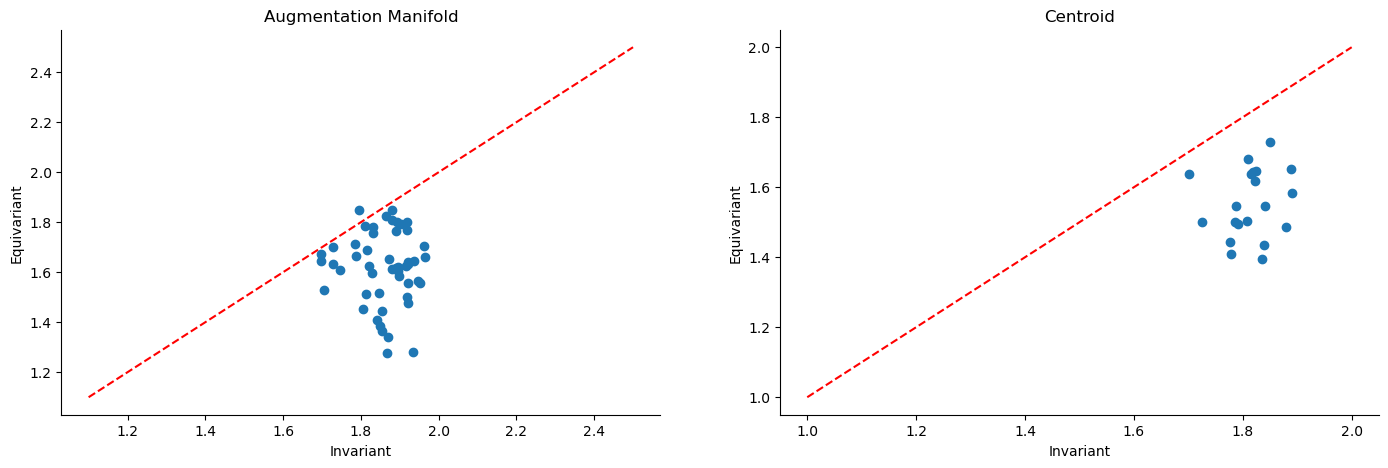

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(17, 5))

axs[0].scatter(
    np.concatenate(augmentation_distance_invariant),
    np.concatenate(augmentation_distance_equivariant),
)
axs[1].scatter(
    np.concatenate(centroid_distance_invariant),
    np.concatenate(centroid_distance_equivariant),
)
# axs[2].scatter(
#     np.concatenate(sp_distance_invariant),
#     np.concatenate(sp_distance_equivariant),
# )

axs[0].set_title("Augmentation Manifold")
axs[1].set_title("Centroid")
# axs[2].set_title("Spatial Photometric")

axs[0].set_xlabel("Invariant")
axs[0].set_ylabel("Equivariant")
axs[1].set_xlabel("Invariant")
axs[1].set_ylabel("Equivariant")
# axs[2].set_xlabel("Invariant")
# axs[2].set_ylabel("Equivariant")

# turn off right/top spines
for ax in axs:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axs[0].plot(
    np.linspace(1.1, 2.5, 100),
    np.linspace(1.1, 2.5, 100),
    color='red',
    linestyle='--',
)

axs[1].plot(
    np.linspace(1, 2, 100),
    np.linspace(1, 2, 100),
    color='red',
    linestyle='--',
)

# axs[2].plot(
#     np.linspace(1.0, 1.8, 100),
#     np.linspace(1.0, 1.8, 100),
#     color='red',
#     linestyle='--',
# )

delta_mean_aug = np.mean(np.concatenate(augmentation_distance_equivariant)) - np.mean(np.concatenate(augmentation_distance_invariant))
delta_mean_centroid = np.mean(np.concatenate(centroid_distance_equivariant)) - np.mean(np.concatenate(centroid_distance_invariant))
# delta_mean_sp = np.mean(np.concatenate(sp_distance_equivariant)) - np.mean(np.concatenate(sp_distance_invariant))

print(f"Augmentation Manifold: {-1.0 * np.real(delta_mean_aug)}")
print(f"Centroid: {-1.0 * np.real(delta_mean_centroid)}")
# print(f"Spatial Photometric: {-1.0 * np.real(delta_mean_sp)}")